# Exploratory Data Analysis (EDA): Spam Email Dataset

This notebook performs an initial exploration of the email dataset to understand class distributions, text length characteristics, and the most frequent vocabulary used in both Spam and Ham emails. This analysis justifies the use of the Multinomial Naive Bayes algorithm.

In [4]:
!pip freeze > requirements.txt

In [7]:
%pip install wordcloud

   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   ----- --------------------------------- 41.0/306.1 kB 653.6 kB/s eta 0:00:01
   ------------------------ --------------- 184.3/306.1 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 2.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set plotting style for professional reports
plt.style.use('ggplot')
sns.set_palette("muted")

## 1. Data Ingestion & Basic Inspection
Loading the dataset from the raw data directory and inspecting the first few rows and general information.

In [9]:
# Define relative path to the raw data
DATA_PATH = '../data/raw/email_data.csv'

# Load the dataset
df = pd.read_csv(DATA_PATH)

print(f"[INFO] Dataset loaded successfully. Shape: {df.shape}")
display(df.head())

print("\n[INFO] Dataset Information:")
display(df.info())

print("\n[INFO] Checking for missing values:")
display(df.isnull().sum())

[INFO] Dataset loaded successfully. Shape: (83448, 2)


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...



[INFO] Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


None


[INFO] Checking for missing values:


label    0
text     0
dtype: int64

## 2. Class Distribution Analysis
Understanding the balance between Spam (1) and Ham (0) emails. Highly imbalanced data might require specific threshold tuning in our Naive Bayes model.

[INFO] Class Distribution:
 - SPAM (1): 43910 samples (52.62%)
 - HAM (0): 39538 samples (47.38%)


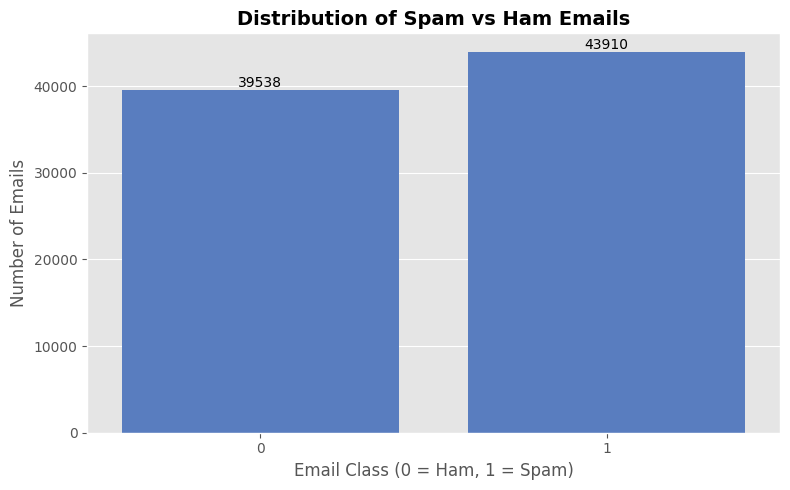

In [10]:
# Calculate value counts and percentages
class_counts = df['label'].value_counts()
class_percentages = df['label'].value_counts(normalize=True) * 100

print("[INFO] Class Distribution:")
for label, count in class_counts.items():
    label_name = "SPAM (1)" if str(label) == '1' else "HAM (0)"
    print(f" - {label_name}: {count} samples ({class_percentages[label]:.2f}%)")

# Plotting the distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label')
plt.title('Distribution of Spam vs Ham Emails', fontsize=14, fontweight='bold')
plt.xlabel('Email Class (0 = Ham, 1 = Spam)')
plt.ylabel('Number of Emails')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## 3. Text Length Analysis
Spam emails often have different length characteristics compared to legitimate emails. Let's engineer a new feature `text_length` to visualize this variance.

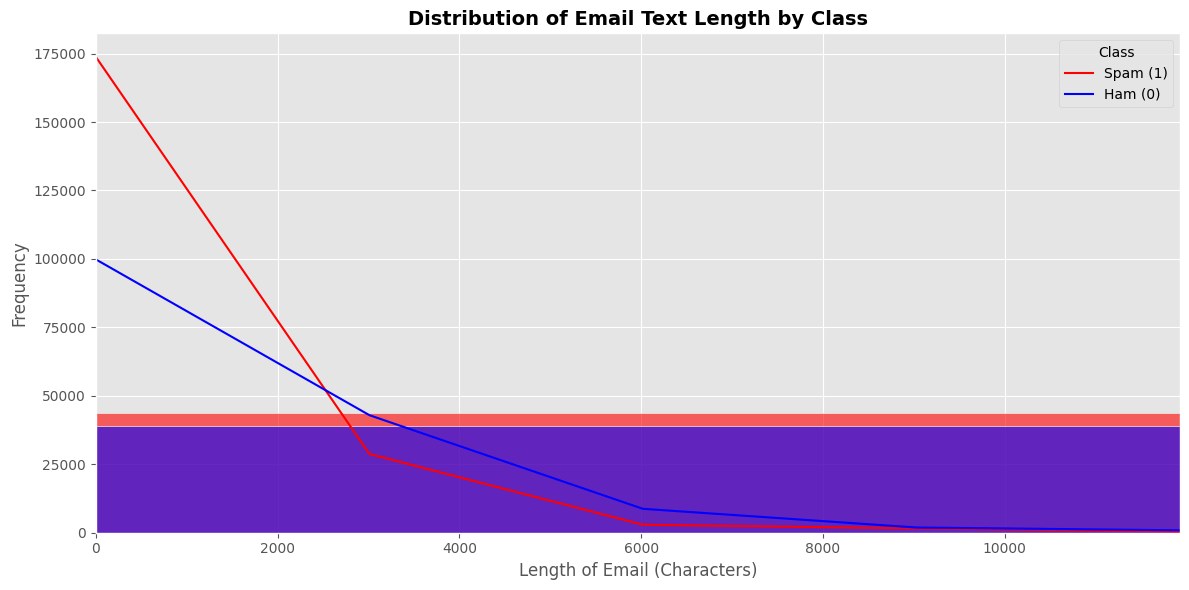

[INFO] Summary statistics for text length:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,39538.0,2121.693814,5666.075286,1.0,579.0,1139.0,2174.0,598705.0
1,43910.0,1249.887247,1978.631507,1.0,360.0,704.0,1510.0,144087.0


In [11]:
# Calculate character length for each email
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(12, 6))

# Use histogram to show length distribution separated by class
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True, 
             palette={0: 'blue', 1: 'red'}, alpha=0.6)

plt.title('Distribution of Email Text Length by Class', fontsize=14, fontweight='bold')
plt.xlabel('Length of Email (Characters)')
plt.ylabel('Frequency')
plt.xlim(0, df['text_length'].quantile(0.99)) # Cut off extreme outliers for better visualization

# Custom legend
plt.legend(title='Class', labels=['Spam (1)', 'Ham (0)'])
plt.tight_layout()
plt.show()

# Display summary statistics
print("[INFO] Summary statistics for text length:")
display(df.groupby('label')['text_length'].describe())

## 4. Vocabulary Analysis (Word Clouds)
Visualizing the most frequently occurring words in both classes. This directly supports the core assumption of Multinomial Naive Bayes: different classes exhibit distinct vocabulary probability distributions (Log-Likelihoods).

[INFO] Generating WordCloud for SPAM emails...


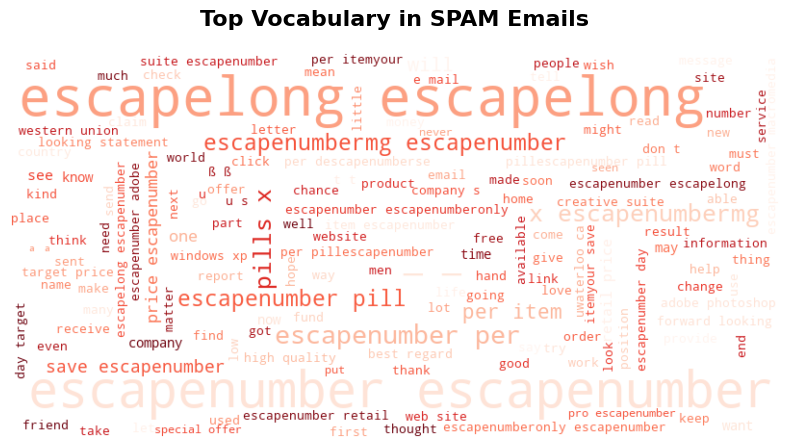

[INFO] Generating WordCloud for HAM emails...


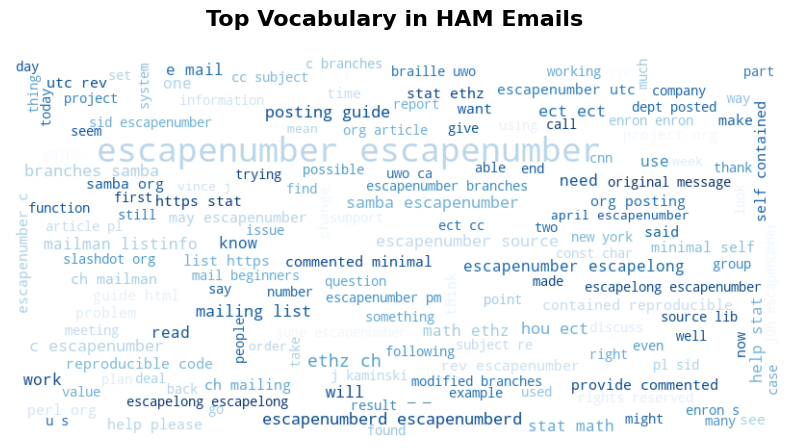

In [12]:
def generate_wordcloud(text_series: pd.Series, title: str, colormap: str):
    """Helper function to generate and display a WordCloud."""
    # Combine all text into a single massive string
    combined_text = " ".join(str(text) for text in text_series)
    
    # Configure WordCloud object
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=colormap,
                          max_words=150).generate(combined_text)
    
    # Display the image
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.show()

# Separate data by class
spam_texts = df[df['label'].astype(str) == '1']['text']
ham_texts = df[df['label'].astype(str) == '0']['text']

print("[INFO] Generating WordCloud for SPAM emails...")
generate_wordcloud(spam_texts, 'Top Vocabulary in SPAM Emails', 'Reds')

print("[INFO] Generating WordCloud for HAM emails...")
generate_wordcloud(ham_texts, 'Top Vocabulary in HAM Emails', 'Blues')

## 5. Model Inference on Unseen Data (Live Testing)
After training the Multinomial Naive Bayes model and saving it as an artifact (`.pkl`), we can load the system memory here to perform live predictions on completely new, unseen text samples.

In [16]:
import os
import sys
import pickle
import pandas as pd

# 1. Environment Path Resolution
# Notebook is in 'notebooks/', so we need to point to the root directory
PROJECT_ROOT = os.path.abspath('..')
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')

# Append 'src' to system path to resolve module imports
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

# 2. Pickle Resolution Hack for Jupyter Environment
import __main__
from train import MultinomialNaiveBayes
__main__.MultinomialNaiveBayes = MultinomialNaiveBayes

# 3. Load the pre-trained model artifact
MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'mnb_model.pkl')

print("[INFO] Loading pre-trained MNB model...")
try:
    with open(MODEL_PATH, 'rb') as f:
        saved_objects = pickle.load(f)
        live_model = saved_objects['model']
    print("[INFO] Model loaded successfully!\n")
except FileNotFoundError:
    print("[-] ERROR: Model artifact not found. Please train the model first.")

# 4. Helper function for quick testing
def predict_live(text: str):
    X_unseen = pd.Series([text])
    prediction = live_model.predict(X_unseen)[0]
    
    result_label = "SPAM 🚫" if str(prediction) == '1' else "HAM ✅"
    display_text = text[:80] + "..." if len(text) > 80 else text
    
    print(f"[{result_label}] {display_text}")

# 5. Execute Live Test Cases
print("=== LIVE INFERENCE RESULTS ===")
predict_live("URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot!")
predict_live("Hi team, please find attached the revised project schedule for the AI report.")
predict_live("You have been selected for a special offer!")
predict_live("You have bad credit history and are eligible for a loan.")
predict_live("There was a problem with your last test. Please contact me immediately (Mr. Adam)")

[INFO] Loading pre-trained MNB model...
[INFO] Model loaded successfully!

=== LIVE INFERENCE RESULTS ===
[SPAM 🚫] URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot!
[HAM ✅] Hi team, please find attached the revised project schedule for the AI report.
[SPAM 🚫] You have been selected for a special offer!
[SPAM 🚫] You have bad credit history and are eligible for a loan.
[HAM ✅] There was a problem with your last test. Please contact me immediately (Mr. Adam...
